# Расчеты 1-7

Загрузка.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, coint, grangercausalitytests, kpss

from read_dataset import load_dataset

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

names = {
    'cpi_all_items_index_2010_100': 'IPC',
    'net_foreign_assets_bln_rub': 'NFA',
    'm2_bln_rub': 'M2',
}
cols = list(names)

df = load_dataset()
df

,date,cpi_all_items_index_2010_100,net_foreign_assets_bln_rub,m2_bln_rub
0,2013-01-01,118.40,1546.894,26348.7
1,2013-02-01,119.07,1716.309,26768.4
2,2013-03-01,119.48,1777.340,27198.6
3,2013-04-01,120.09,1871.582,27377.1
4,2013-05-01,120.89,2320.501,27593.4
5,2013-06-01,121.39,2062.333,28212.3
6,2013-07-01,122.39,2057.608,28443.9
7,2013-08-01,122.57,1947.753,28499.9
8,2013-09-01,122.82,1748.925,28352.6
9,2013-10-01,123.53,1746.729,28276.4


Проверка.

In [2]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   date                          30 non-null     datetime64[ns]
 1   cpi_all_items_index_2010_100  30 non-null     float64       
 2   net_foreign_assets_bln_rub    30 non-null     float64       
 3   m2_bln_rub                    30 non-null     float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 1.1 KB


date                            0
cpi_all_items_index_2010_100    0
net_foreign_assets_bln_rub      0
m2_bln_rub                      0
dtype: int64

Графики уровней.

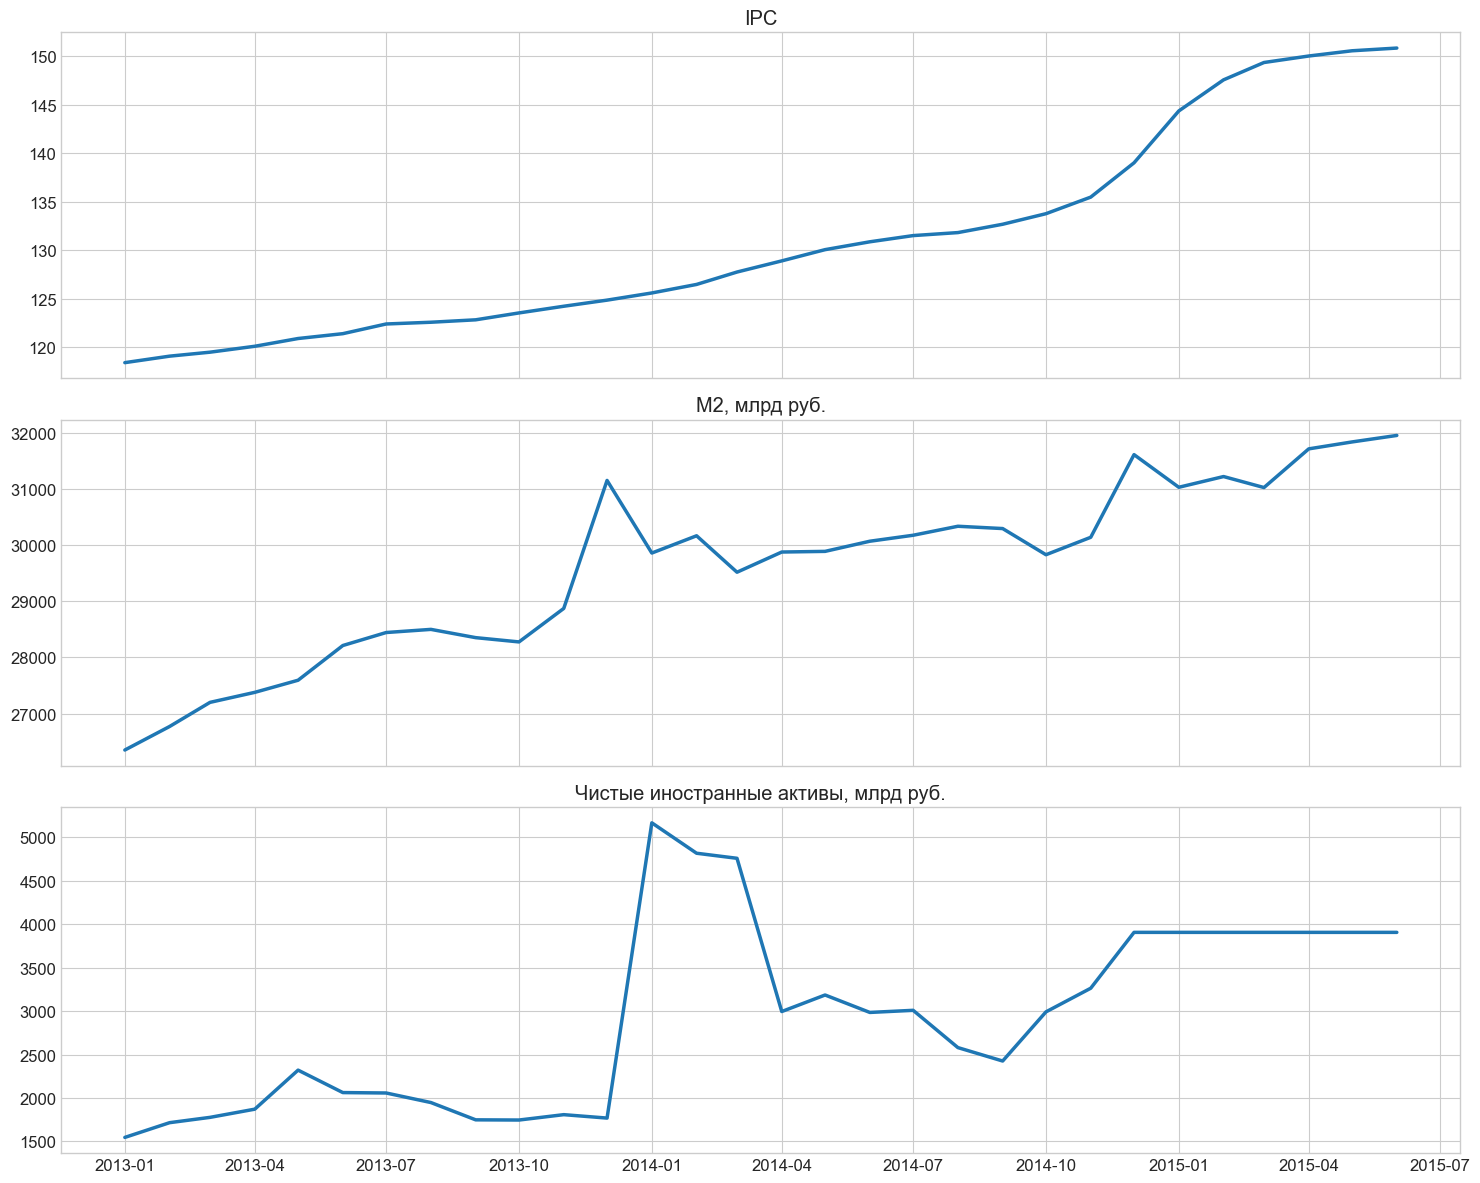

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
columns = [
    ('cpi_all_items_index_2010_100', 'IPC'),
    ('m2_bln_rub', 'M2, млрд руб.'),
    ('net_foreign_assets_bln_rub', 'Чистые иностранные активы, млрд руб.'),
]

for ax, (col, title) in zip(axes, columns):
    ax.plot(df['date'], df[col], linewidth=2.5)
    ax.set_title(title)

plt.tight_layout()

Логи.

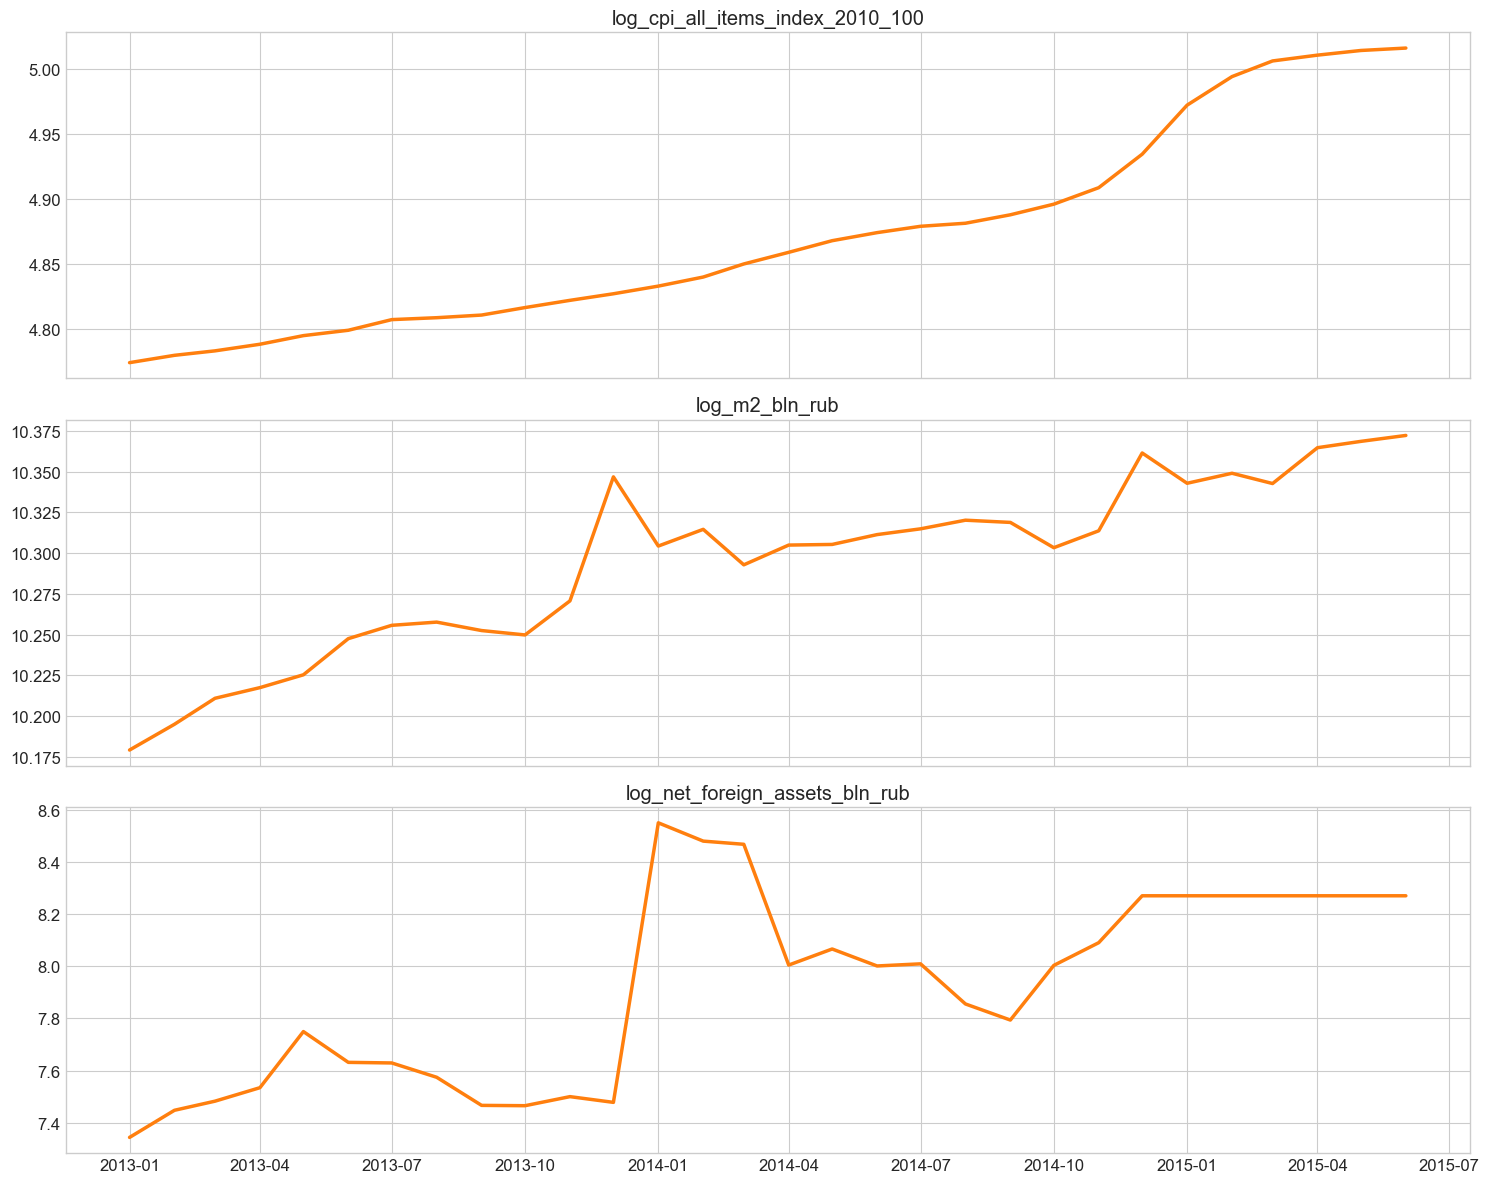

In [4]:
log_df = df.copy()
for col in ['cpi_all_items_index_2010_100', 'm2_bln_rub', 'net_foreign_assets_bln_rub']:
    log_df[f'log_{col}'] = np.log(log_df[col])

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
for ax, col in zip(axes, ['log_cpi_all_items_index_2010_100', 'log_m2_bln_rub', 'log_net_foreign_assets_bln_rub']):
    ax.plot(log_df['date'], log_df[col], linewidth=2.5, color='tab:orange')
    ax.set_title(col)

plt.tight_layout()

Описание.

In [5]:
desc = df.drop(columns='date').describe().T[['mean', 'std', 'min', 'max']]
desc

,mean,std,min,max
cpi_all_items_index_2010_100,130.880667,10.490669,118.400,150.860
net_foreign_assets_bln_rub,2928.927167,1069.628520,1546.894,5164.019
m2_bln_rub,29590.046667,1580.305180,26348.700,31958.000


Приросты.

In [6]:
growth = df.copy()
for col in ['cpi_all_items_index_2010_100', 'm2_bln_rub', 'net_foreign_assets_bln_rub']:
    growth[f'{col}_pct_change'] = growth[col].pct_change() * 100

growth.filter(regex='date|pct_change').head()

,date,cpi_all_items_index_2010_100_pct_change,m2_bln_rub_pct_change,net_foreign_assets_bln_rub_pct_change
0,2013-01-01,NaN,NaN,NaN
1,2013-02-01,0.565878,1.592868,10.951946
2,2013-03-01,0.344335,1.607119,3.555945
3,2013-04-01,0.510546,0.656284,5.302418
4,2013-05-01,0.666167,0.790076,23.986072


Корреляции.

In [7]:
df.drop(columns='date').corr().round(3)

,cpi_all_items_index_2010_100,net_foreign_assets_bln_rub,m2_bln_rub
cpi_all_items_index_2010_100,1.000,0.632,0.863
net_foreign_assets_bln_rub,0.632,1.000,0.689
m2_bln_rub,0.863,0.689,1.000


ACF и PACF.

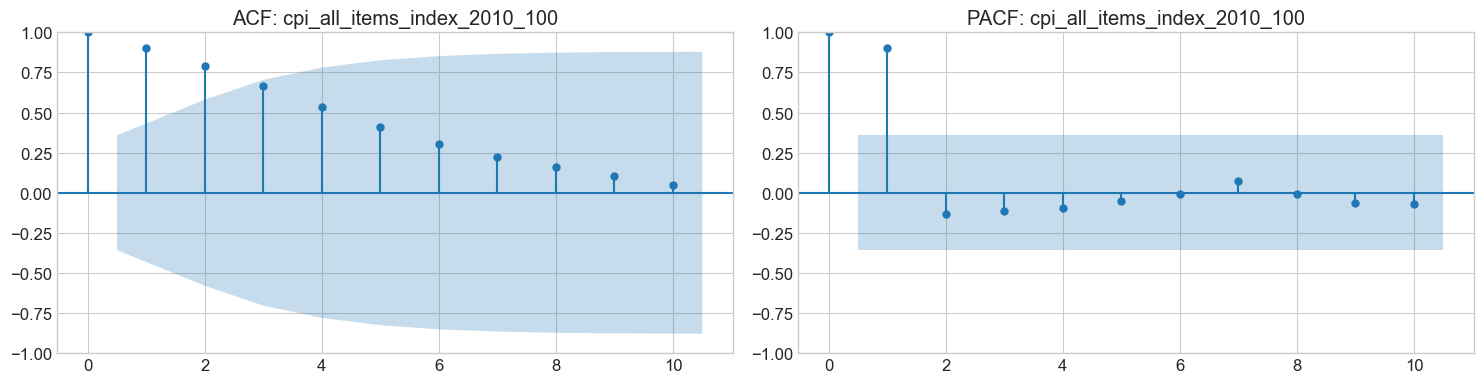

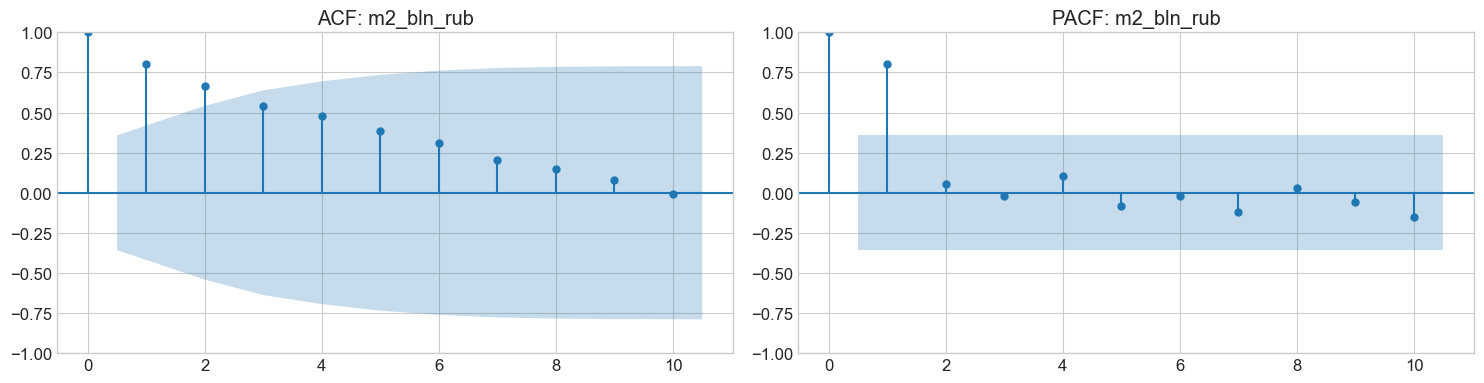

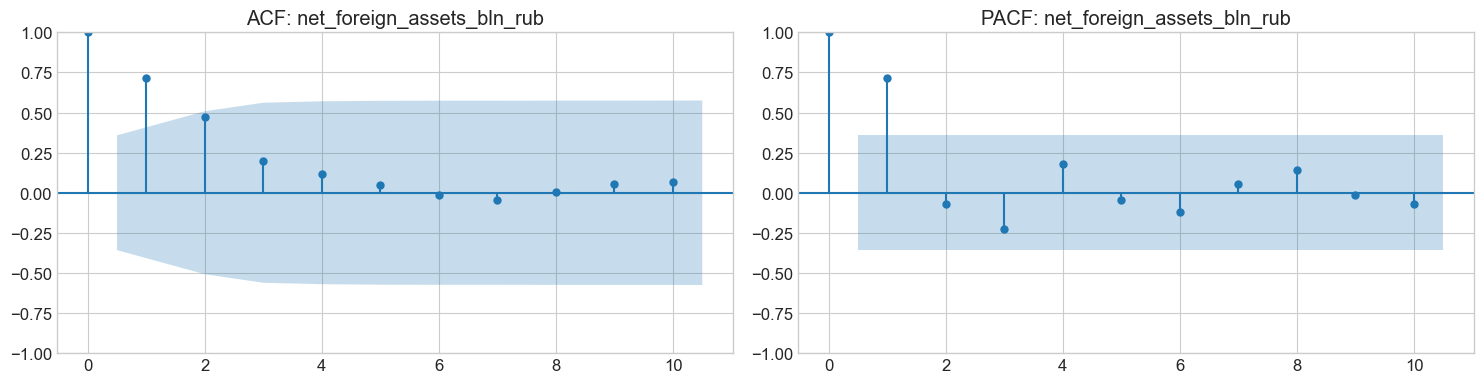

In [8]:
for col in ['cpi_all_items_index_2010_100', 'm2_bln_rub', 'net_foreign_assets_bln_rub']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    plot_acf(df[col], lags=min(10, len(df) // 2 - 1), ax=axes[0])
    plot_pacf(df[col], lags=min(10, len(df) // 2 - 2), ax=axes[1], method='ywm')
    axes[0].set_title(f'ACF: {col}')
    axes[1].set_title(f'PACF: {col}')
    plt.tight_layout()
    plt.show()

Стационарность.

In [9]:
def adf_test(series):
    stat, pvalue, *_ = adfuller(series.dropna(), autolag='AIC')
    return stat, pvalue


def kpss_test(series):
    stat, pvalue, *_ = kpss(series.dropna(), regression='c', nlags='auto')
    return stat, pvalue


rows = []
for col in cols:
    variants = {
        'level': df[col],
        'dlog': np.log(df[col]).diff(),
        'ddlog': np.log(df[col]).diff().diff(),
    }
    for form, series in variants.items():
        adf_stat, adf_p = adf_test(series)
        kpss_stat, kpss_p = kpss_test(series)
        rows.append([names[col], form, adf_stat, adf_p, kpss_stat, kpss_p])

stationarity = pd.DataFrame(rows, columns=['series', 'form', 'adf_stat', 'adf_p', 'kpss_stat', 'kpss_p'])
stationarity.round(4)

,series,form,adf_stat,adf_p,kpss_stat,kpss_p
0,IPC,level,3.1230,1.0000,0.7898,0.0100
1,IPC,dlog,2.4623,0.9990,0.2582,0.1000
2,IPC,ddlog,-3.5098,0.0077,0.1032,0.1000
3,NFA,level,-2.0989,0.2450,0.5371,0.0333
4,NFA,dlog,-5.5420,0.0000,0.0475,0.1000
5,NFA,ddlog,-9.4412,0.0000,0.0381,0.1000
6,M2,level,-1.6203,0.4725,0.8153,0.0100
7,M2,dlog,-6.9888,0.0000,0.2218,0.1000
8,M2,ddlog,-3.3505,0.0128,0.1197,0.1000


Рабочая форма.

In [10]:
work_df = pd.DataFrame({
    'date': df['date'],
    'd2log_cpi': np.log(df['cpi_all_items_index_2010_100']).diff().diff(),
    'dlog_nfa': np.log(df['net_foreign_assets_bln_rub']).diff(),
    'dlog_m2': np.log(df['m2_bln_rub']).diff(),
}).dropna().reset_index(drop=True)

work_df.head()

,date,d2log_cpi,dlog_nfa,dlog_m2
0,2013-03-01,-0.002205,0.034942,0.015943
1,2013-04-01,0.001655,0.051666,0.006541
2,2013-05-01,0.001547,0.214999,0.007870
3,2013-06-01,-0.002512,-0.117945,0.022181
4,2013-07-01,0.004077,-0.002294,0.008176


Коинтеграция.

In [11]:
pairs = [
    ('cpi_all_items_index_2010_100', 'net_foreign_assets_bln_rub'),
    ('cpi_all_items_index_2010_100', 'm2_bln_rub'),
    ('net_foreign_assets_bln_rub', 'm2_bln_rub'),
]

coint_rows = []
for left, right in pairs:
    stat, pvalue, _ = coint(np.log(df[left]), np.log(df[right]))
    coint_rows.append([names[left], names[right], stat, pvalue])

coint_table = pd.DataFrame(coint_rows, columns=['left', 'right', 'stat', 'pvalue'])
coint_table.round(4)

,left,right,stat,pvalue
0,IPC,NFA,-1.3674,0.8085
1,IPC,M2,-2.0411,0.5071
2,NFA,M2,-3.7742,0.0147


Причинность.

In [12]:
maxlag = 3
series_cols = ['d2log_cpi', 'dlog_nfa', 'dlog_m2']

rows = []
for caused in series_cols:
    for causing in series_cols:
        if caused == causing:
            continue
        tests = grangercausalitytests(work_df[[caused, causing]], maxlag=maxlag, verbose=False)
        pvalues = [tests[lag][0]['ssr_ftest'][1] for lag in range(1, maxlag + 1)]
        best_lag = int(np.argmin(pvalues) + 1)
        rows.append([causing, caused, best_lag, min(pvalues), min(pvalues) < 0.05])

granger_table = pd.DataFrame(rows, columns=['cause', 'effect', 'best_lag', 'min_pvalue', 'significant'])
granger_table.round(4)

,cause,effect,best_lag,min_pvalue,significant
0,dlog_nfa,d2log_cpi,2,0.6272,False
1,dlog_m2,d2log_cpi,2,0.0888,False
2,d2log_cpi,dlog_nfa,3,0.7936,False
3,dlog_m2,dlog_nfa,1,0.0002,True
4,d2log_cpi,dlog_m2,3,0.9206,False
5,dlog_nfa,dlog_m2,3,0.2563,False


Схема связей.

In [13]:
links = granger_table.query('significant == True')[['cause', 'effect', 'best_lag', 'min_pvalue']]
links.round(4)

,cause,effect,best_lag,min_pvalue
3,dlog_m2,dlog_nfa,1,0.0002


Лаги VAR.

In [14]:
var_data = work_df.set_index('date')[series_cols]
var_model = VAR(var_data)
lag_selection = var_model.select_order(maxlags=3)
lag_selection.summary()

,AIC,BIC,FPE,HQIC
0,-20.65,-20.51*,1.073e-09,-20.61
1,-20.79,-20.21,9.412e-10*,-20.63*
2,-20.66,-19.64,1.115e-09,-20.38
3,-20.83*,-19.37,1.033e-09,-20.43


Сравнение VAR.

In [15]:
model_rows = []
for lag in [1, 2, 3]:
    result = var_model.fit(lag)
    model_rows.append([lag, result.aic, result.bic, result.hqic, result.is_stable()])

model_compare = pd.DataFrame(model_rows, columns=['lag', 'AIC', 'BIC', 'HQIC', 'stable'])
model_compare.round(4)

,lag,AIC,BIC,HQIC,stable
0,1,-21.0375,-20.4615,-20.8662,True
1,2,-20.7900,-19.7738,-20.4974,True
2,3,-20.8326,-19.3700,-20.4269,True


Оценка VAR.

In [16]:
best_lag = 1
var_result = var_model.fit(best_lag)
var_result.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 01, Jun, 2026
Time:                     22:34:32
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.4615
Nobs:                     27.0000    HQIC:                  -20.8662
Log likelihood:           181.072    FPE:                7.35198e-10
AIC:                     -21.0375    Det(Omega_mle):     4.85747e-10
--------------------------------------------------------------------
Results for equation d2log_cpi
                  coefficient       std. error           t-stat            prob
-------------------------------------------------------------------------------
const               -0.000832         0.001152           -0.722           0.470
L1.d2log_cpi         0.237656         0.189557            1.254           0.210
L1.dlog_nfa          0.004542         0.004902            0.

Диагностика VAR.

In [17]:
diag = pd.DataFrame({
    'series': series_cols,
    'durbin_watson': durbin_watson(var_result.resid),
})

whiteness = var_result.test_whiteness(nlags=8)
normality = var_result.test_normality()

print('stable:', var_result.is_stable())
print('whiteness pvalue:', round(whiteness.pvalue, 4))
print('normality pvalue:', round(normality.pvalue, 4))
diag.round(4)

stable: True
whiteness pvalue: 0.9065
normality pvalue: 0.0


,series,durbin_watson
0,d2log_cpi,1.6174
1,dlog_nfa,2.3043
2,dlog_m2,2.0930


Остатки.

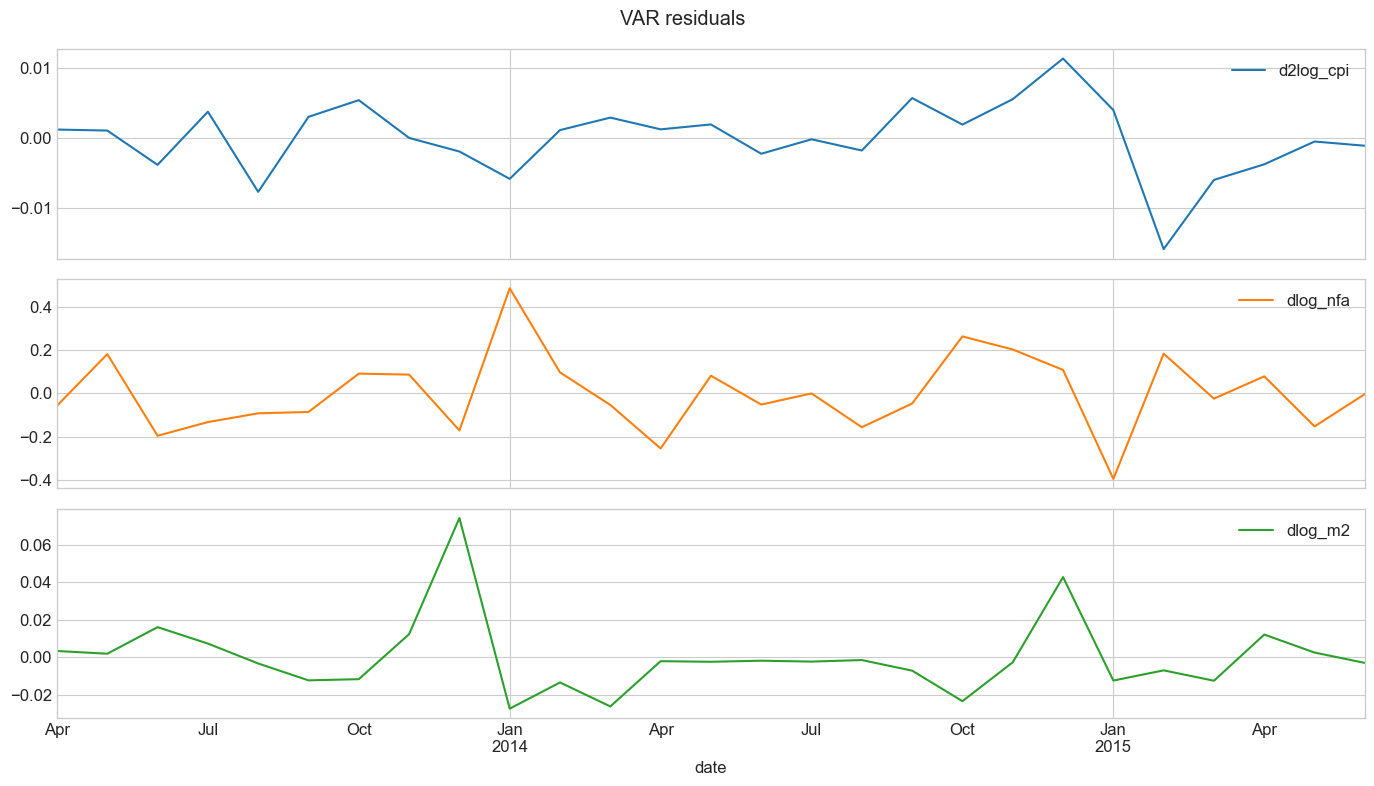

In [18]:
var_result.resid.plot(subplots=True, figsize=(14, 8), title='VAR residuals')
plt.tight_layout()

ECM.

In [19]:
long_run = sm.OLS(
    np.log(df['m2_bln_rub']),
    sm.add_constant(np.log(df['net_foreign_assets_bln_rub']))
).fit()

ecm = pd.DataFrame({
    'dlog_m2': np.log(df['m2_bln_rub']).diff(),
    'dlog_nfa': np.log(df['net_foreign_assets_bln_rub']).diff(),
    'ect_lag': long_run.resid.shift(1),
}).dropna()

ecm_result = sm.OLS(ecm['dlog_m2'], sm.add_constant(ecm[['dlog_nfa', 'ect_lag']])).fit()
ecm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                dlog_m2   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     2.366
Date:                Mon, 01 Jun 2026   Prob (F-statistic):              0.114
Time:                        22:34:32   Log-Likelihood:                 73.861
No. Observations:                  29   AIC:                            -141.7
Df Residuals:                      26   BIC:                            -137.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0073      0.004      1.938      0.064      -0.000       0.015
dlog_nfa      -0.0255      0.020     -1.294      0.207      -0.066       0.015
ect_lag       -0.0880      0.129     -0.684      0.500      -0.352       0.176
==============================================================================
Omnibus:                       25.821   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               48.762
Skew:                           1.931   Prob(JB):                     2.58e-11
Kurtosis:                       8.043   Cond. No.                         34.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

IRF.

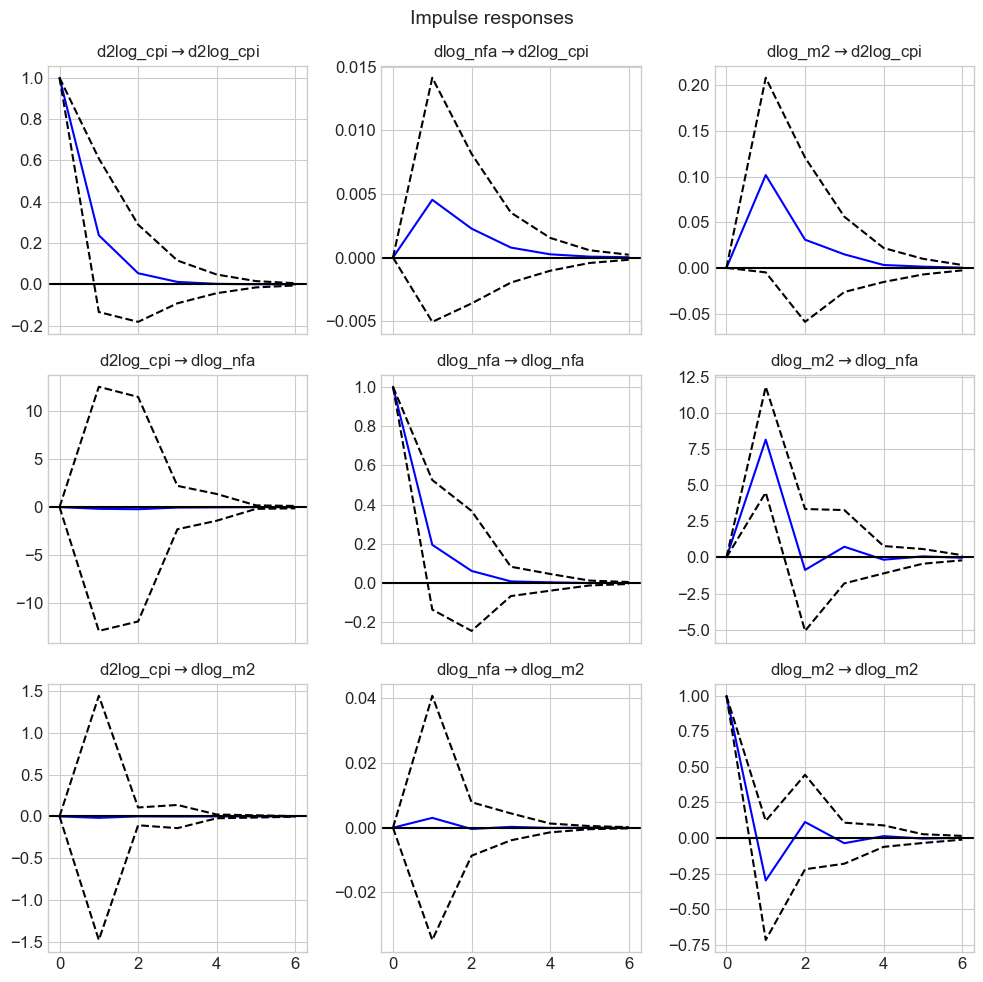

In [20]:
irf = var_result.irf(6)
irf.plot(orth=False)
plt.tight_layout()

FEVD.

In [21]:
fevd = var_result.fevd(6)
fevd.summary()

FEVD for d2log_cpi
     d2log_cpi  dlog_nfa   dlog_m2
0     1.000000  0.000000  0.000000
1     0.876505  0.002471  0.121024
2     0.865637  0.004227  0.130136
3     0.863378  0.004333  0.132289
4     0.863259  0.004356  0.132384
5     0.863241  0.004357  0.132402

FEVD for dlog_nfa
     d2log_cpi  dlog_nfa   dlog_m2
0     0.014677  0.985323  0.000000
1     0.010965  0.544624  0.444411
2     0.011195  0.543590  0.445215
3     0.011178  0.541651  0.447171
4     0.011181  0.541576  0.447243
5     0.011181  0.541557  0.447262

FEVD for dlog_m2
     d2log_cpi  dlog_nfa   dlog_m2
0     0.011713  0.062710  0.925577
1     0.012164  0.066657  0.921178
2     0.012169  0.066784  0.921047
3     0.012174  0.066819  0.921007
4     0.012174  0.066822  0.921004
5     0.012174  0.066823  0.921003




Итоговые таблицы.

In [22]:
final_tables = {
    'stationarity': stationarity.round(4),
    'cointegration': coint_table.round(4),
    'granger': granger_table.round(4),
    'models': model_compare.round(4),
}

final_tables

{'stationarity':   series   form  adf_stat   adf_p  kpss_stat  kpss_p
 0    IPC  level    3.1230  1.0000     0.7898  0.0100
 1    IPC   dlog    2.4623  0.9990     0.2582  0.1000
 2    IPC  ddlog   -3.5098  0.0077     0.1032  0.1000
 3    NFA  level   -2.0989  0.2450     0.5371  0.0333
 4    NFA   dlog   -5.5420  0.0000     0.0475  0.1000
 5    NFA  ddlog   -9.4412  0.0000     0.0381  0.1000
 6     M2  level   -1.6203  0.4725     0.8153  0.0100
 7     M2   dlog   -6.9888  0.0000     0.2218  0.1000
 8     M2  ddlog   -3.3505  0.0128     0.1197  0.1000,
 'cointegration':   left right    stat  pvalue
 0  IPC   NFA -1.3674  0.8085
 1  IPC    M2 -2.0411  0.5071
 2  NFA    M2 -3.7742  0.0147,
 'granger':        cause     effect  best_lag  min_pvalue  significant
 0   dlog_nfa  d2log_cpi         2      0.6272        False
 1    dlog_m2  d2log_cpi         2      0.0888        False
 2  d2log_cpi   dlog_nfa         3      0.7936        False
 3    dlog_m2   dlog_nfa         1      0.0002        

Итог.

In [23]:
summary = pd.DataFrame({
    'item': ['observations', 'period', 'main_model', 'ecm_pair'],
    'value': [len(df), f"{df['date'].min().date()} - {df['date'].max().date()}", 'VAR(1)', 'NFA-M2'],
})
summary

,item,value
0,observations,30
1,period,2013-01-01 - 2015-06-01
2,main_model,VAR(1)
3,ecm_pair,NFA-M2
